In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
from scipy.stats import normaltest
from sklearn.metrics import roc_curve, auc
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats 
import random
import scipy

gpp.set_aesthetics(context = 'paper')

In [16]:
reads_df=pd.read_table("../Data/counts-STS_A375_A549_CP0081.txt")
reads_df=reads_df.drop(["Construct IDs","Unlabeled Sample Barcodes"],axis=1)
reads_df

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,920,1448,1319,1254,437
1,AAAAACAGCTGATGAAACCT,681,804,1049,1383,390
2,AAAAACCTGGGAAAGATATA,1270,2073,2501,2248,480
3,AAAAAGAGGCGGCATTACAG,1224,1382,2850,2305,688
4,AAAAAGATAGATGTGCTAAA,92,296,236,258,521
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,2405,4048,2532,2478,619
60546,TTTGTGGGTACATCTAACCC,1647,901,2052,1142,427
60547,TTTGTGGTAGGAGTAGGTGT,260,110,671,757,531
60548,TTTGTGTATTACCTCAGGAA,921,4601,1357,1606,488


In [17]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['A375_CP0081_rep A',
       'A375_CP0081_rep B', 'A549_CP0081_rep A', 'A549_CP0081_rep B',
       'CP0081 pDNA']
lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove('CP0081 pDNA')
lognorm_df

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,3.824139,3.860735,3.773873,3.875863,3.826832
1,AAAAACAGCTGATGAAACCT,3.425472,3.089369,3.470337,4.007931,3.674873
2,AAAAACCTGGGAAAGATATA,4.260914,4.348138,4.646206,4.673847,3.953096
3,AAAAAGAGGCGGCATTACAG,4.210515,3.798166,4.827590,4.708574,4.444031
4,AAAAAGATAGATGTGCTAAA,1.211874,1.912777,1.708646,1.931577,4.063996
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,5.146165,5.278646,4.663273,4.809126,4.298931
60546,TTTGTGGGTACATCTAACCC,4.618598,3.235336,4.373283,3.750494,3.795814
60547,TTTGTGGTAGGAGTAGGTGT,2.238852,1.019814,2.897232,3.210808,4.089800
60548,TTTGTGTATTACCTCAGGAA,3.825596,5.458910,3.811892,4.211096,3.975415


In [18]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['CP0081 pDNA'] - filtered_lognorms['CP0081 pDNA'].mean())/filtered_lognorms['CP0081 pDNA'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,3.824139,3.860735,3.773873,3.875863,3.826832
1,AAAAACAGCTGATGAAACCT,3.425472,3.089369,3.470337,4.007931,3.674873
2,AAAAACCTGGGAAAGATATA,4.260914,4.348138,4.646206,4.673847,3.953096
3,AAAAAGAGGCGGCATTACAG,4.210515,3.798166,4.827590,4.708574,4.444031
4,AAAAAGATAGATGTGCTAAA,1.211874,1.912777,1.708646,1.931577,4.063996
...,...,...,...,...,...,...
60365,TTTGTGGAGCCGGTACATGA,5.146165,5.278646,4.663273,4.809126,4.298931
60366,TTTGTGGGTACATCTAACCC,4.618598,3.235336,4.373283,3.750494,3.795814
60367,TTTGTGGTAGGAGTAGGTGT,2.238852,1.019814,2.897232,3.210808,4.089800
60368,TTTGTGTATTACCTCAGGAA,3.825596,5.458910,3.811892,4.211096,3.975415


In [19]:
#get log fold change from pDNA
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["CP0081 pDNA"]
lfc_df=lfc_df.drop("CP0081 pDNA",axis=1)
lfc_df

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B
0,AAAAAAGAAAGGATACGTCC,-0.002693,0.033903,-0.052959,0.049031
1,AAAAACAGCTGATGAAACCT,-0.249401,-0.585504,-0.204536,0.333058
2,AAAAACCTGGGAAAGATATA,0.307818,0.395042,0.693110,0.720751
3,AAAAAGAGGCGGCATTACAG,-0.233516,-0.645865,0.383559,0.264543
4,AAAAAGATAGATGTGCTAAA,-2.852123,-2.151219,-2.355350,-2.132420
...,...,...,...,...,...
60365,TTTGTGGAGCCGGTACATGA,0.847234,0.979715,0.364341,0.510194
60366,TTTGTGGGTACATCTAACCC,0.822784,-0.560478,0.577470,-0.045320
60367,TTTGTGGTAGGAGTAGGTGT,-1.850948,-3.069986,-1.192567,-0.878991
60368,TTTGTGTATTACCTCAGGAA,-0.149819,1.483495,-0.163523,0.235681


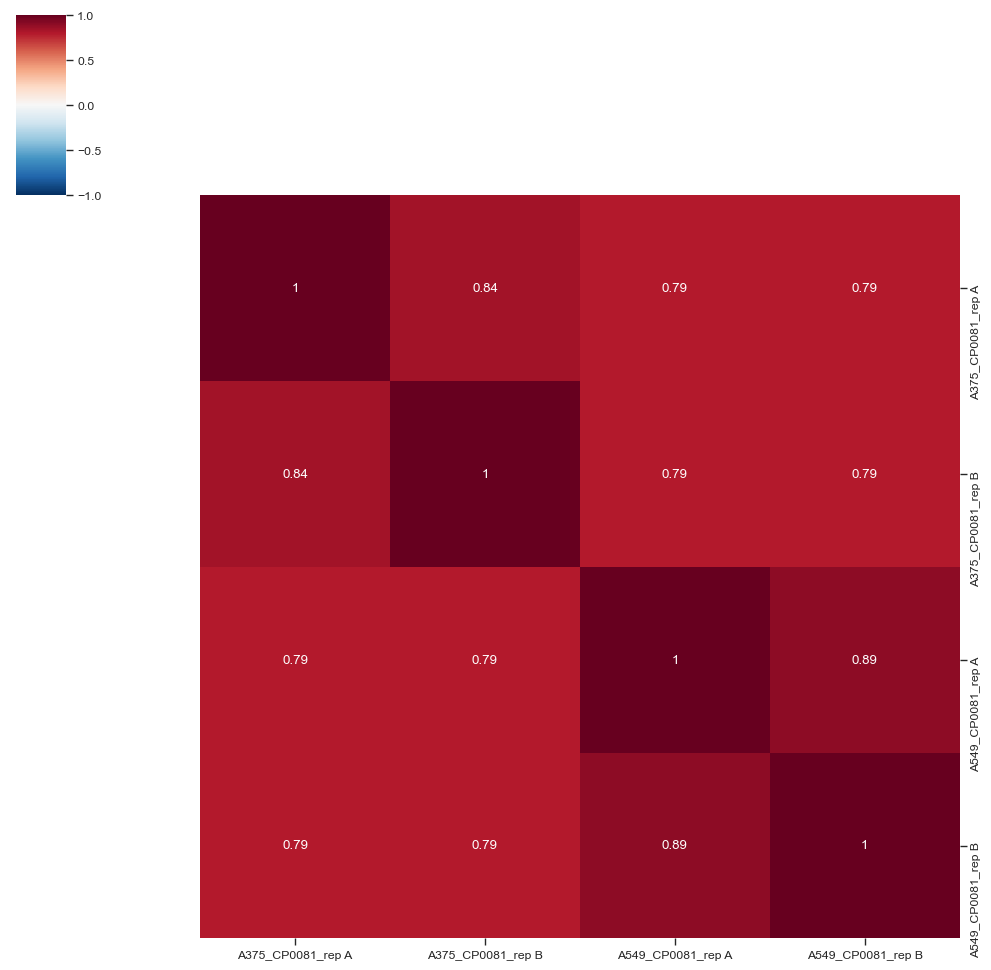

In [20]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=True,row_cluster=False,col_cluster=False)
gpp.savefig("../Figures/jacquere_splitvector_replicate_correlation.pdf")

In [21]:
#Replicate correlation is satisfactory: average replicates

condition_map = {'A375_CP0081_rep A': 'Jacquere A375',
                 'A375_CP0081_rep B': 'Jacquere A375',
                 'A549_CP0081_rep A': 'Jacquere A549',
                 'A549_CP0081_rep B': 'Jacquere A549'}

long_lfcs = (lfc_df.melt(id_vars='Construct Barcode',
                         var_name='condition', value_name='lfc'))

long_lfcs['condition'] = long_lfcs['condition'].map(condition_map)
lfcs_replicates_averaged = (long_lfcs.groupby(['Construct Barcode', 'condition'])
            .agg(sgRNA_lfc = ('lfc', 'mean'))
            .reset_index())
lfcs_replicates_averaged

,Construct Barcode,condition,sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,0.015605
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.001964
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.417453
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.064261
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.351430
...,...,...,...
120735,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-1.035779
120736,TTTGTGTATTACCTCAGGAA,Jacquere A375,0.666838
120737,TTTGTGTATTACCTCAGGAA,Jacquere A549,0.036079
120738,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.071269


In [22]:
#read in guide level annotations (supplementary file from manuscript)
guide_mappings_compressed = pd.read_csv("../Data/Jacquere_PerGuideAnnotations.csv")

#get target-level information as a unique row (guides that have numerous targets are thus repeated)
guide_mapping=guide_mappings_compressed.apply(lambda x: x.str.split("|")).explode(column=[col for col in guide_mappings_compressed.columns if col not in ["sgRNA Sequence","Other Target Matches"]])
guide_mapping["sgRNA Sequence"]=guide_mapping["sgRNA Sequence"].apply(lambda x: "".join(x))
guide_mapping=guide_mapping.drop("Other Target Matches",axis=1)

#identify additional genes to which each guide maps; gene effects should be determined from ALL mapping guides, regardless of intended target
guides_with_additional_genesmapped= guide_mappings_compressed[guide_mappings_compressed["Other Target Matches"]!="[]"][["sgRNA Sequence","Other Target Matches"]]
guides_with_additional_genesmapped["Other Target Matches"]=guides_with_additional_genesmapped["Other Target Matches"].apply(lambda x: x.strip("[]").replace("'", "").split(", ") if x != '[]' else list())
guides_with_additional_genesmapped=guides_with_additional_genesmapped.explode("Other Target Matches")
guides_with_additional_genesmapped=guides_with_additional_genesmapped.rename(columns={"Other Target Matches":"Target Gene Symbol"})
guides_with_additional_genesmapped=guides_with_additional_genesmapped.drop_duplicates()
guide_mapping=pd.concat([guide_mapping,guides_with_additional_genesmapped])
#for guides with NA gene symbol, use Gene ID instead
guide_mapping["Target Gene Symbol"]=guide_mapping.apply(lambda x: x["Target Gene ID"] if x["Target Gene Symbol"]=="nan" else x["Target Gene Symbol"],axis=1)
guide_mapping

,sgRNA Sequence,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,GTAGTGACCTCCATCCCCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58351487,5,1.9481,0,0,1.138
1,ACTGGCGCCATCGAGAGCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58352536,4,1.5,0,0,0.928
2,GTGGAGTGGACTTCCAGCTA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,-,58351575,5,0.0,0,0,1.212
3,ATGACTCTCATACTCCACGA,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50836128,6,0.7222,0,0,1.453
4,GAAGACAGGAGCTCCAAGGT,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50816123,9,0.0,0,0,1.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59545,CATTGGTATCCAAAACACTG,NaN,NaN,KMT2E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59546,AAGATCATGAAAAATACGGT,NaN,NaN,MRPL30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
#join data with guide annotations
annotated_sgrna_lfcs = lfcs_replicates_averaged.merge(guide_mapping,how='inner',left_on='Construct Barcode',right_on="sgRNA Sequence")
annotated_sgrna_lfcs=annotated_sgrna_lfcs.drop("sgRNA Sequence",axis=1)
annotated_sgrna_lfcs

,Construct Barcode,condition,sgRNA_lfc,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,0.015605,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.001964,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.417453,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.064261,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.351430,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131809,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-1.035779,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859
131810,TTTGTGTATTACCTCAGGAA,Jacquere A375,0.666838,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131811,TTTGTGTATTACCTCAGGAA,Jacquere A549,0.036079,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131812,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.071269,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445


Statistics=370.828, p=0.000 length= 1800


Text(0.5, 0, 'Log2 fold change')

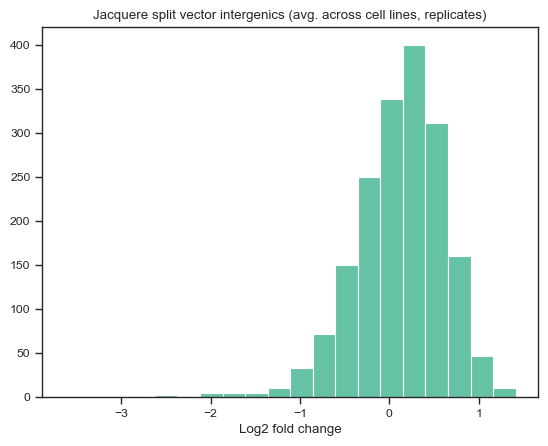

In [24]:
control_sgrna_lfcs = annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Target Gene Symbol'].str.count("INTERGENIC")>0)].reset_index(drop=True)

#testing if controls are normally distributed with D'Agostino-Pearson K2 test
stat, p = normaltest(control_sgrna_lfcs["sgRNA_lfc"])
print('Statistics=%.3f, p=%.3f' % (stat, p),"length=",len(control_sgrna_lfcs))

control_sgrna_lfcs["sgRNA_lfc"].hist(grid=False,bins=20)
plt.title("Jacquere split vector intergenics (avg. across cell lines, replicates)")
plt.xlabel("Log2 fold change")

The result of the D'Agostino-Pearson K2 demonstrates that the controls are normally distributed

In [25]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('sgRNA_lfc', 'mean'),
                            neg_ctl_sd = ('sgRNA_lfc', 'std'))
                       .reset_index())

zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs['sgRNA_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean','sgRNA_lfc'], axis=1)
zscored_sgrna_lfcs

,Construct Barcode,condition,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score,z_scored_sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-0.191589
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-0.268737
2,AAAAACAGCTGATGAAACCT,Jacquere A375,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,-0.942683
3,AAAAACAGCTGATGAAACCT,Jacquere A549,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,-0.111045
4,AAAAACCTGGGAAAGATATA,Jacquere A375,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958,0.390865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131809,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859,-2.730405
131810,TTTGTGTATTACCTCAGGAA,Jacquere A375,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,0.937908
131811,TTTGTGTATTACCTCAGGAA,Jacquere A549,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,-0.178151
131812,TTTGTTGGATACGAAGTGAA,Jacquere A375,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445,-0.095046


### Identifying Jacquere vs. Brunello Library Performance

Identifying performance of library at separating essentials, nonessentials and comparing to screen of Brunello Library (Sanson et al, *Nature Communications*, 2018)

In [26]:
brunello_zscores=pd.read_csv("../Data/brunello_zscores.csv")
brunello_zscores = brunello_zscores.rename(columns={'sgRNA Sequence': 'Construct Barcode'})
brunello_zscores["condition"]="Brunello A375"
jacquere_and_brunello=pd.concat([zscored_sgrna_lfcs,brunello_zscores])

In [27]:
noness_genes = pd.read_csv("../Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
noness_genes["Gene"]=noness_genes["Gene"].str.replace(" ","")

essential_genes = pd.read_csv("../Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
essential_genes["Gene"]=essential_genes["Gene"].str.replace(" ","")

In [28]:
# ROC-AUC of essential vs nonessential genes 

jacquere_and_brunello_eval =  jacquere_and_brunello.copy()
jacquere_and_brunello_eval['Essential'] = jacquere_and_brunello_eval['Target Gene Symbol'].isin(essential_genes["Gene"].tolist())
jacquere_and_brunello_eval['Nonessential'] = jacquere_and_brunello_eval['Target Gene Symbol'].isin(noness_genes["Gene"].tolist())
jacquere_and_brunello_eval = (jacquere_and_brunello_eval[jacquere_and_brunello_eval['Essential'] | jacquere_and_brunello_eval['Nonessential']].reset_index(drop=True))
tpr_fpr_df_list = []
roc_auc_list = []
for group, df in jacquere_and_brunello_eval.groupby('condition'):
    fpr, tpr, threshold = roc_curve(df['Essential'], -df['z_scored_sgRNA_lfc'])
    group_tpr_fpr_df = pd.DataFrame({'True Positive Rate': tpr, 'False Positive Rate': fpr, 'threshold': threshold})
    group_tpr_fpr_df['condition'] = group
    tpr_fpr_df_list.append(group_tpr_fpr_df)
    roc_auc = auc(fpr, tpr)
    roc_auc_list.append({'condition': group, 'ROC-AUC': roc_auc})
sgrna_roc_aucs = pd.DataFrame(roc_auc_list)
sgrna_tpr_fpr_df = (pd.concat(tpr_fpr_df_list).reset_index(drop=True))


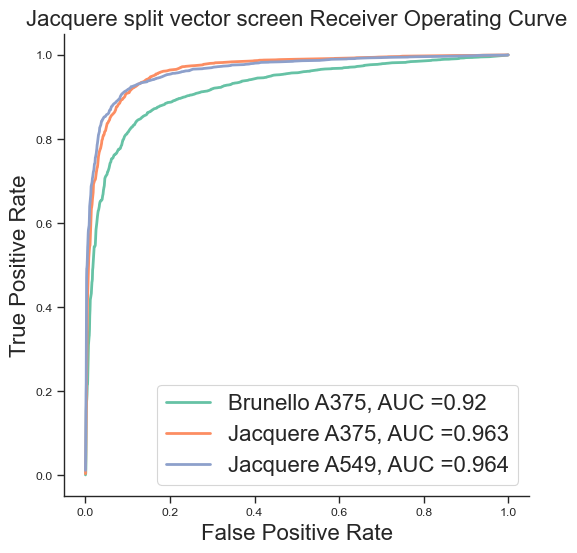

In [34]:
ROC_AUC_map = sgrna_roc_aucs.set_index('condition').to_dict()
sgrna_tpr_fpr_df['ROC-AUC'] = sgrna_tpr_fpr_df['condition'].map(ROC_AUC_map["ROC-AUC"])
sgrna_tpr_fpr_df["Screen"]=sgrna_tpr_fpr_df['condition']+", AUC ="+round(sgrna_tpr_fpr_df['ROC-AUC'],3).astype(str)

plt.subplots(figsize=(6, 6))
sns.lineplot(data=sgrna_tpr_fpr_df, x='False Positive Rate', linewidth=2,
             y='True Positive Rate', hue='Screen', errorbar=None)
plt.legend(fontsize=16)
plt.xlabel(xlabel="False Positive Rate",fontsize=16)
plt.ylabel(ylabel="True Positive Rate",fontsize=16)
plt.title("Jacquere split vector screen Receiver Operating Curve",fontsize=16)
sns.despine()
gpp.savefig("../Figures/Jacquere_splitvector_vs_Brunello_ROC.pdf")

Calculating precision recall curve 

In [30]:
def calc_precision(data,predicted_cutoff):
    true_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Essential"])])
    false_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Nonessential"])])
    total_positive_predictions= true_positives + false_positives
    return (true_positives/total_positive_predictions)
def calc_recall(data,predicted_cutoff):
    true_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Essential"])])
    false_negatives= len(data.loc[(data["z_scored_sgRNA_lfc"]>predicted_cutoff) & (data["Essential"])])
    total_actual_positives= true_positives + false_negatives
    return (true_positives/total_actual_positives)
    
def calc_precision_recall(df):
    cutoff_precision_full=[]
    cutoff_recall_full=[]
    cutoffs_totest=[x*0.01 for x in range(round(df["z_scored_sgRNA_lfc"].min() *100)+1,round(df["z_scored_sgRNA_lfc"].max()) *100)]
    for cutoff in cutoffs_totest :
        cutoff_precision_full.append(calc_precision(df,predicted_cutoff=cutoff))
        cutoff_recall_full.append(calc_recall(df,predicted_cutoff=cutoff))
    return cutoff_precision_full, cutoff_recall_full 

jacquere_A549_precision,jacquere_A549_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Jacquere A549"])
jacquere_A375_precision,jacquere_A375_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Jacquere A375"])
brunello_A375_precision,brunello_A375_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Brunello A375"])


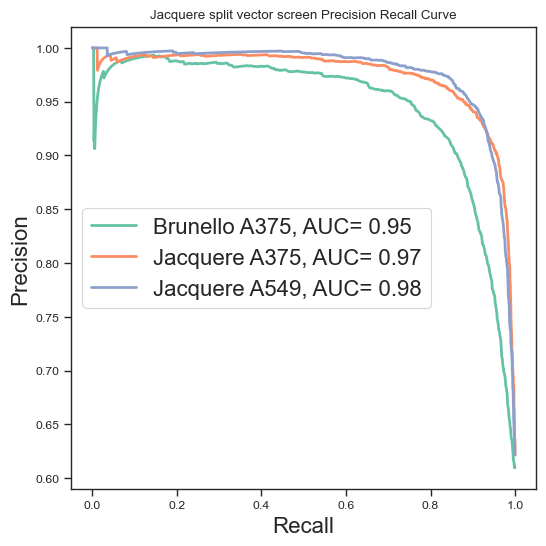

In [33]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(brunello_A375_recall, brunello_A375_precision, label= f'Brunello A375, AUC= {round(auc(brunello_A375_recall, brunello_A375_precision),2)}',linewidth=2)
ax.plot(jacquere_A375_recall, jacquere_A375_precision, label= f'Jacquere A375, AUC= {round(auc(jacquere_A375_recall, jacquere_A375_precision),2)}',linewidth=2)
ax.plot(jacquere_A549_recall, jacquere_A549_precision, label= f'Jacquere A549, AUC= {round(auc(jacquere_A549_recall, jacquere_A549_precision),2)}',linewidth=2)

ax.set_xlabel('Recall',fontsize=16)
ax.set_ylabel('Precision',fontsize=16)
ax.legend(loc='center left',fontsize=16)
ax.set_title("Jacquere split vector screen Precision Recall Curve")
gpp.savefig("../Figures/Jacquere_splitvector_vs_Brunello_PRC.pdf")